In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [ ]:
# Use relative path 

df = pd.read_csv("C:\\Users\\sriva\\Downloads\\data\\q2_customers.csv")

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,46,119757,3,5256,48,7
1,56,118757,2,7818,126,6
2,45,118676,1,7021,157,9
3,61,118168,4,4649,81,7
4,61,117977,4,6512,72,7


In [3]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.384951,2.160012,-1.017809,1.132457,-0.029527,0.961498
1,1.078808,2.129546,-1.205805,2.259760,1.541488,0.550952
2,0.315566,2.127078,-1.393801,1.909073,2.165866,1.782589
3,1.425736,2.111602,-0.829814,0.865372,0.635133,0.961498
4,1.425736,2.105783,-0.829814,1.685108,0.453862,0.961498


#Why Scaling is Important for K-Means

K-Means uses Euclidean distance, so feature scale matters.

- Features with larger values dominate clustering
- Leads to biased clusters

StandardScaler ensures:
- Mean = 0, Std = 1
- Equal contribution from all features

This improves clustering accuracy.

In [5]:
#Elbow Method
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

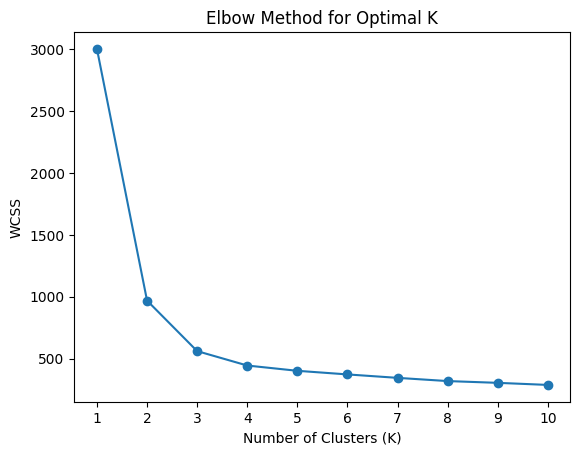

In [6]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()


- WCSS decreases as K increases
- Sharp bend observed at K = 3

Optimal number of clusters = 3

In [7]:
#Task 3: K-Means Clustering

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,46,119757,3,5256,48,7,2
1,56,118757,2,7818,126,6,2
2,45,118676,1,7021,157,9,2
3,61,118168,4,4649,81,7,2
4,61,117977,4,6512,72,7,2


In [8]:
centroids_scaled = kmeans.cluster_centers_

centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])

centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
1,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
2,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152


#Cluster Interpretation

**Cluster 0: High-Value Customers**
- High spend, frequent visits, large basket size
- Target with loyalty programs

**Cluster 1: Moderate Customers**
- high engagement
- Can be improved via offers

**Cluster 2: Low-Engagement**
- Low spend, infrequent visits
- At risk of churn → need re-engagement

In [9]:
#Task 4: PCA (Dimensionality Reduction)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

df_pca.head()

,PC1,PC2
0,2.340157,-0.767021
1,3.579285,0.283717
2,3.943080,0.907081
3,2.812537,-0.338437
4,3.079200,-0.663594


In [10]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557


In [11]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


# Interpretation of Principal Components

PC1: Customer Value
- High loadings: spend, visits, basket size
- Represents overall engagement

PC2: Recency & Behavior
- Captures last visit, diversity
- Helps separate inactive vs active users

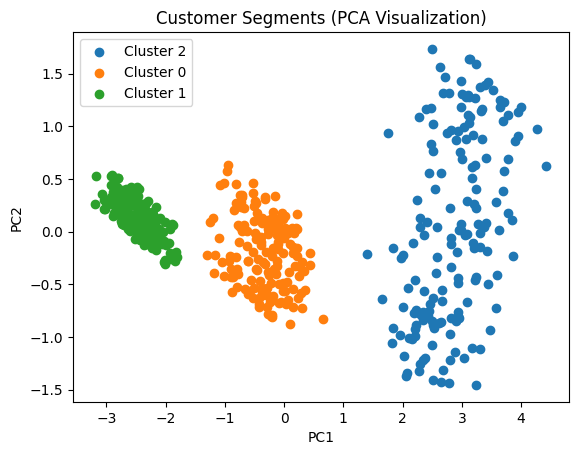

In [12]:
df_pca['cluster'] = df['cluster']

for cluster in df_pca['cluster'].unique():
    subset = df_pca[df_pca['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

plt.show()